# ---------- Data loading notebook ----------

The goal of this notebook is to load and combine London bike-sharing trip data from 2024 and 2025.

Author: Artur Werys

In [29]:
from pathlib import Path
import pandas as pd
import xml.etree.ElementTree as et

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [30]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

DATA_2024_DIR = DATA_DIR / "2024"
DATA_2025_DIR = DATA_DIR / "2025"

STATIONS_FILE = DATA_DIR / "stations.xml"

## ---------- Loading CSV data function ----------


In [31]:
def load_data(folder_path):
    files = list(folder_path.glob("*.csv"))
    dataframes = []

    for file in files:
        df = pd.read_csv(file)
        dataframes.append(df)

    combined_data = pd.concat(dataframes, ignore_index=True)

    return combined_data

## ---------- Loading data from choosen years ----------


In [32]:
print("--- Loading data from 2025... ---")

data_2025 = load_data(DATA_2025_DIR)

print(data_2025.head())
print("Number of trips in 2025:", len(data_2025))


print("--- Loading data from 2024... ---")

data_2024 = load_data(DATA_2024_DIR)

print(data_2024.head())
print("Number of trips in 2024:", len(data_2024))

--- Loading data from 2025... ---
      Number        Start date  Start station number  \
0  145666816  2025-01-14 23:59                  1043   
1  145666817  2025-01-14 23:59                300015   
2  145666818  2025-01-14 23:59                  1068   
3  145666819  2025-01-14 23:59                  1159   
4  145666812  2025-01-14 23:58                200048   

                      Start station          End date  End station number  \
0        Museum of London, Barbican  2025-01-15 00:13            200149.0   
1          Binfield Road, Stockwell  2025-01-15 00:04            300229.0   
2  Norton Folgate, Liverpool Street  2025-01-15 00:10              1051.0   
3         Berry Street, Clerkenwell  2025-01-15 00:10              1007.0   
4          Page Street, Westminster  2025-01-15 00:14              1058.0   

                        End station  Bike number  Bike model Total duration  \
0           Watney Street, Shadwell        55223     CLASSIC        14m 30s   
1       

### ---------- Combining datasets ----------


In [33]:
combined_trip_data = pd.concat(
    [data_2024, data_2025],
    ignore_index=True
)

### ---------- Renaming columns ----------


In [34]:
combined_trip_data = combined_trip_data.rename(columns={
    "Number": "trip_id",
    "Start date": "start_date",
    "End date": "end_date",
    "Start station number": "start_station_id",
    "Start station": "start_station_name",
    "End station number": "end_station_id",
    "End station": "end_station_name",
    "Bike number": "bike_id",
    "Bike model": "bike_model",
    "Total duration": "total_duration",
    "Total duration (ms)": "total_duration_ms",
})

combined_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms
0,145207079,2024-12-14 23:59,300083,"Duke Street Hill, London Bridge",2024-12-14 23:59,300083.0,"Duke Street Hill, London Bridge",57763.0,CLASSIC,29s,29203.0
1,145207080,2024-12-14 23:59,1133,"Baylis Road, Waterloo",2024-12-15 00:26,200011.0,"Furze Green, Bow",62625.0,PBSC_EBIKE,27m 0s,1620164.0
2,145207081,2024-12-14 23:59,3447,"Gloucester Road (North), Kensington",2024-12-15 00:17,200181.0,"Richmond Way, Shepherd's Bush",62291.0,PBSC_EBIKE,18m 16s,1096981.0
3,145207082,2024-12-14 23:59,1112,"Nutford Place, Marylebone",2024-12-15 00:12,3422.0,"Charlbert Street, St. John's Wood",50575.0,CLASSIC,13m 3s,783763.0
4,145207083,2024-12-14 23:59,1122,"Ashley Place, Victoria",2024-12-15 00:04,200048.0,"Page Street, Westminster",52143.0,CLASSIC,5m 22s,322155.0


### ---------- Checking for missing values in combined data ----------


In [35]:
print("Missing values in each column:")
print(combined_trip_data.isna().sum())

len_before_dropping = len(combined_trip_data)

print("Dropping rows with missing data...")

combined_trip_data = combined_trip_data.dropna(
    subset=["end_date", "end_station_id", "bike_id"]
)

len_after_dropping = len(combined_trip_data)

dropped_rows_count = len_before_dropping - len_after_dropping

print("Missing values in each column after dropping rows with missing data:")
print(combined_trip_data.isna().sum())

print(f"Number of dropped rows: {dropped_rows_count}")

Missing values in each column:
trip_id                 0
start_date              0
start_station_id        0
start_station_name      0
end_date              184
end_station_id        184
end_station_name      184
bike_id                 1
bike_model              0
total_duration        184
total_duration_ms     184
dtype: int64
Dropping rows with missing data...
Missing values in each column after dropping rows with missing data:
trip_id               0
start_date            0
start_station_id      0
start_station_name    0
end_date              0
end_station_id        0
end_station_name      0
bike_id               0
bike_model            0
total_duration        0
total_duration_ms     0
dtype: int64
Number of dropped rows: 185


## ---------- Loading station data from XML ----------


In [36]:
tree = et.parse(STATIONS_FILE)
root = tree.getroot()

stations_data = []

for station in root.findall("station"):

    station_data = [
        station.find("name").text.strip(),
        station.find("lat").text,
        station.find("long").text
    ]

    stations_data.append(station_data)

stations_df = pd.DataFrame(
    stations_data,
    columns=[
        "station_name",
        "latitude",
        "longitude"
    ]
)

print("--- Station data loaded from XML ---")
print(stations_df.head())
print("Number of stations:", len(stations_df))

--- Station data loaded from XML ---
                           station_name     latitude     longitude
0            River Street , Clerkenwell  51.52916347  -0.109970527
1        Phillimore Gardens, Kensington  51.49960695  -0.197574246
2  Christopher Street, Liverpool Street  51.52128377  -0.084605692
3       St. Chad's Street, King's Cross  51.53005939  -0.120973687
4         Sedding Street, Sloane Square     51.49313     -0.156876
Number of stations: 801


### ---------- Merging stations from trip data with geograpical data ----------


In [37]:
combined_trip_data = pd.merge(combined_trip_data, stations_df, left_on="start_station_name", right_on="station_name", how ="left")
combined_trip_data = combined_trip_data.rename(columns={
    "latitude": "start_lat",
    "longitude": "start_lon"
})

combined_trip_data = combined_trip_data.drop(columns=["station_name"])
combined_trip_data.head()

combined_trip_data = pd.merge(combined_trip_data, stations_df, left_on="end_station_name", right_on="station_name", how ="left")
combined_trip_data = combined_trip_data.rename(columns={
    "latitude": "end_lat",
    "longitude": "end_lon"
})

combined_trip_data = combined_trip_data.drop(columns=["station_name"])
combined_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,145207079,2024-12-14 23:59,300083,"Duke Street Hill, London Bridge",2024-12-14 23:59,300083.0,"Duke Street Hill, London Bridge",57763.0,CLASSIC,29s,29203.0,51.50630441,-0.087262995,51.50630441,-0.087262995
1,145207080,2024-12-14 23:59,1133,"Baylis Road, Waterloo",2024-12-15 00:26,200011.0,"Furze Green, Bow",62625.0,PBSC_EBIKE,27m 0s,1620164.0,51.50144456,-0.110699309,51.519265,-0.021345
2,145207081,2024-12-14 23:59,3447,"Gloucester Road (North), Kensington",2024-12-15 00:17,200181.0,"Richmond Way, Shepherd's Bush",62291.0,PBSC_EBIKE,18m 16s,1096981.0,51.49792478,-0.183834706,51.50035306,-0.217515071
3,145207082,2024-12-14 23:59,1112,"Nutford Place, Marylebone",2024-12-15 00:12,3422.0,"Charlbert Street, St. John's Wood",50575.0,CLASSIC,13m 3s,783763.0,51.5165179,-0.164393768,51.53430039,-0.1680743
4,145207083,2024-12-14 23:59,1122,"Ashley Place, Victoria",2024-12-15 00:04,200048.0,"Page Street, Westminster",52143.0,CLASSIC,5m 22s,322155.0,51.49616092,-0.140947636,51.493978,-0.127554


### ---------- Deleting trips without geographical data ----------


In [38]:
final_trip_data = combined_trip_data.dropna(subset=["start_lat", "start_lon", "end_lat", "end_lon"])

# How many trips were deleted?
print(f"Percentage of trips deleted: {((len(combined_trip_data) - len(final_trip_data)) / len(combined_trip_data) * 100):.2f}%")


Percentage of trips deleted: 2.23%


## ---------- Saving final trip data as parquet ----------


In [39]:
final_trip_data["start_date"] = pd.to_datetime(
    final_trip_data["start_date"],
    format="mixed",
    dayfirst=True
)

final_trip_data["end_date"] = pd.to_datetime(
    final_trip_data["end_date"],
    format="mixed",
    dayfirst=True
)

final_trip_data.to_parquet(DATA_DIR / "final_trip_data.parquet")

/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_4918/2951280931.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_trip_data["start_date"] = pd.to_datetime(
/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_4918/2951280931.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_trip_data["end_date"] = pd.to_datetime(


In [40]:
final_trip_data.head()

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,145207079,2024-12-14 23:59:00,300083,"Duke Street Hill, London Bridge",2024-12-14 23:59:00,300083.0,"Duke Street Hill, London Bridge",57763.0,CLASSIC,29s,29203.0,51.50630441,-0.087262995,51.50630441,-0.087262995
1,145207080,2024-12-14 23:59:00,1133,"Baylis Road, Waterloo",2024-12-15 00:26:00,200011.0,"Furze Green, Bow",62625.0,PBSC_EBIKE,27m 0s,1620164.0,51.50144456,-0.110699309,51.519265,-0.021345
2,145207081,2024-12-14 23:59:00,3447,"Gloucester Road (North), Kensington",2024-12-15 00:17:00,200181.0,"Richmond Way, Shepherd's Bush",62291.0,PBSC_EBIKE,18m 16s,1096981.0,51.49792478,-0.183834706,51.50035306,-0.217515071
3,145207082,2024-12-14 23:59:00,1112,"Nutford Place, Marylebone",2024-12-15 00:12:00,3422.0,"Charlbert Street, St. John's Wood",50575.0,CLASSIC,13m 3s,783763.0,51.5165179,-0.164393768,51.53430039,-0.1680743
4,145207083,2024-12-14 23:59:00,1122,"Ashley Place, Victoria",2024-12-15 00:04:00,200048.0,"Page Street, Westminster",52143.0,CLASSIC,5m 22s,322155.0,51.49616092,-0.140947636,51.493978,-0.127554


In [41]:
final_trip_data.head(-5)

,trip_id,start_date,start_station_id,start_station_name,end_date,end_station_id,end_station_name,bike_id,bike_model,total_duration,total_duration_ms,start_lat,start_lon,end_lat,end_lon
0,145207079,2024-12-14 23:59:00,300083,"Duke Street Hill, London Bridge",2024-12-14 23:59:00,300083.0,"Duke Street Hill, London Bridge",57763.0,CLASSIC,29s,29203.0,51.50630441,-0.087262995,51.50630441,-0.087262995
1,145207080,2024-12-14 23:59:00,1133,"Baylis Road, Waterloo",2024-12-15 00:26:00,200011.0,"Furze Green, Bow",62625.0,PBSC_EBIKE,27m 0s,1620164.0,51.50144456,-0.110699309,51.519265,-0.021345
2,145207081,2024-12-14 23:59:00,3447,"Gloucester Road (North), Kensington",2024-12-15 00:17:00,200181.0,"Richmond Way, Shepherd's Bush",62291.0,PBSC_EBIKE,18m 16s,1096981.0,51.49792478,-0.183834706,51.50035306,-0.217515071
3,145207082,2024-12-14 23:59:00,1112,"Nutford Place, Marylebone",2024-12-15 00:12:00,3422.0,"Charlbert Street, St. John's Wood",50575.0,CLASSIC,13m 3s,783763.0,51.5165179,-0.164393768,51.53430039,-0.1680743
4,145207083,2024-12-14 23:59:00,1122,"Ashley Place, Victoria",2024-12-15 00:04:00,200048.0,"Page Street, Westminster",52143.0,CLASSIC,5m 22s,322155.0,51.49616092,-0.140947636,51.493978,-0.127554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17823198,146319209,2025-02-15 00:01:00,1163,"Wardour Street, Soho",2025-02-15 00:23:00,1210.0,"Nevern Place, Earl's Court",62970.0,PBSC_EBIKE,21m 55s,1315266.0,51.51251523,-0.133201961,51.49334336,-0.194757949
17823199,146319210,2025-02-15 00:01:00,1163,"Wardour Street, Soho",2025-02-15 00:23:00,1210.0,"Nevern Place, Earl's Court",63362.0,PBSC_EBIKE,21m 47s,1307848.0,51.51251523,-0.133201961,51.49334336,-0.194757949
17823200,146319211,2025-02-15 00:01:00,1220,"Imperial College, Knightsbridge",2025-02-15 00:27:00,1207.0,"Tavistock Street, Covent Garden",53794.0,CLASSIC,25m 59s,1559056.0,51.49942855,-0.179702476,51.51196803,-0.120718759
17823201,146319212,2025-02-15 00:01:00,2692,"Waterloo Station 2, Waterloo",2025-02-15 01:46:00,200178.0,"Buckingham Gate, Westminster",54259.0,CLASSIC,1h 44m 52s,6292435.0,51.50391973,-0.11342629,51.49886563,-0.137424571


## ---------- Average road distance between stations ----------


In [45]:
import math

import networkx as nx
import osmnx as ox

ROAD_DISTANCE_DIR = DATA_DIR / "osm_route_cache" / "road_distances"
ROAD_DISTANCE_DIR.mkdir(parents=True, exist_ok=True)

ROAD_GRAPH_FILE = ROAD_DISTANCE_DIR / "london_bike_network.graphml"
STATION_NODES_FILE = ROAD_DISTANCE_DIR / "station_nearest_nodes.parquet"
PAIR_ROAD_DISTANCES_FILE = DATA_DIR / "station_pair_road_distances.parquet"


def station_table_from_trips(trip_data):
    start_stations = trip_data[["start_station_name", "start_lat", "start_lon"]].rename(columns={
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lon": "lon",
    })
    end_stations = trip_data[["end_station_name", "end_lat", "end_lon"]].rename(columns={
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lon": "lon",
    })

    stations = pd.concat([start_stations, end_stations], ignore_index=True).dropna()
    stations["lat"] = stations["lat"].astype(float)
    stations["lon"] = stations["lon"].astype(float)
    return stations.groupby("station_name", as_index=False).agg(lat=("lat", "mean"), lon=("lon", "mean"))


def bbox_around_station_table(stations_table, buffer_meters=1200):
    mean_lat = math.radians(stations_table["lat"].mean())
    lat_margin = buffer_meters / 111_320
    lon_margin = buffer_meters / (111_320 * max(math.cos(mean_lat), 0.1))

    left = stations_table["lon"].min() - lon_margin
    bottom = stations_table["lat"].min() - lat_margin
    right = stations_table["lon"].max() + lon_margin
    top = stations_table["lat"].max() + lat_margin
    return left, bottom, right, top


def graph_covers_station_table(graph, stations_table, margin_degrees=0.002):
    node_lons = [float(data["x"]) for _, data in graph.nodes(data=True)]
    node_lats = [float(data["y"]) for _, data in graph.nodes(data=True)]

    return (
        min(node_lons) <= stations_table["lon"].min() - margin_degrees
        and max(node_lons) >= stations_table["lon"].max() + margin_degrees
        and min(node_lats) <= stations_table["lat"].min() - margin_degrees
        and max(node_lats) >= stations_table["lat"].max() + margin_degrees
    )


def nearest_graph_nodes_without_optional_dependencies(graph, stations_table):
    try:
        return ox.distance.nearest_nodes(
            graph,
            stations_table["lon"].to_numpy(),
            stations_table["lat"].to_numpy(),
        )
    except ImportError as error:
        print("OSMnx nearest_nodes needs an optional package in this environment:", error)
        print("Using a simple fallback nearest-node search instead.")

    graph_nodes = [
        (node, float(data["x"]), float(data["y"]))
        for node, data in graph.nodes(data=True)
    ]

    nearest_nodes = []
    for station in stations_table.itertuples(index=False):
        station_lon = float(station.lon)
        station_lat = float(station.lat)
        nearest_node = min(
            graph_nodes,
            key=lambda item: (item[1] - station_lon) ** 2 + (item[2] - station_lat) ** 2,
        )[0]
        nearest_nodes.append(nearest_node)

    return nearest_nodes


In [46]:
station_coordinates = station_table_from_trips(final_trip_data)
print("Stations with coordinates:", len(station_coordinates))

if ROAD_GRAPH_FILE.exists():
    print("Loading cached road graph:", ROAD_GRAPH_FILE)
    road_graph = ox.load_graphml(ROAD_GRAPH_FILE)
else:
    road_graph = None
    existing_graph_paths = sorted(
        (DATA_DIR / "osm_route_cache").glob("london_bike_graph_*.graphml"),
        key=lambda graph_path: graph_path.stat().st_size,
        reverse=True,
    )

    for graph_path in existing_graph_paths:
        candidate_graph = ox.load_graphml(graph_path)
        if graph_covers_station_table(candidate_graph, station_coordinates):
            print("Reusing existing graph cache:", graph_path)
            road_graph = candidate_graph
            ox.save_graphml(road_graph, ROAD_GRAPH_FILE)
            break

    if road_graph is None:
        print("Downloading London bike network for road-distance statistics...")
        ox.settings.use_cache = True
        ox.settings.cache_folder = str(DATA_DIR / "osm_route_cache" / "http_cache")
        ox.settings.log_console = False

        road_bbox = bbox_around_station_table(station_coordinates, buffer_meters=1200)
        try:
            road_graph = ox.graph_from_bbox(
                road_bbox,
                network_type="bike",
                simplify=True,
                retain_all=False,
                truncate_by_edge=True,
            )
        except TypeError:
            left, bottom, right, top = road_bbox
            road_graph = ox.graph_from_bbox(
                top,
                bottom,
                right,
                left,
                network_type="bike",
                simplify=True,
                retain_all=False,
                truncate_by_edge=True,
            )
        ox.save_graphml(road_graph, ROAD_GRAPH_FILE)
        print("Saved road graph:", ROAD_GRAPH_FILE)

if STATION_NODES_FILE.exists():
    station_nodes_df = pd.read_parquet(STATION_NODES_FILE)
else:
    nearest_nodes = nearest_graph_nodes_without_optional_dependencies(
        road_graph,
        station_coordinates,
    )
    station_nodes_df = station_coordinates.copy()
    station_nodes_df["nearest_node"] = nearest_nodes
    station_nodes_df.to_parquet(STATION_NODES_FILE, index=False)

station_nodes_df.head()


Stations with coordinates: 801
Loading cached road graph: Data/osm_route_cache/road_distances/london_bike_network.graphml
OSMnx nearest_nodes needs an optional package in this environment: scikit-learn must be installed as an optional dependency to search an unprojected graph.
Using a simple fallback nearest-node search instead.


,station_name,lat,lon,nearest_node
0,"Abbey Orchard Street, Westminster",51.498126,-0.132102,25378075
1,"Abbotsbury Road, Holland Park",51.501391,-0.205991,7416302958
2,"Aberdeen Place, St. John's Wood",51.524826,-0.176268,614477396
3,"Aberfeldy Street, Poplar",51.513548,-0.005659,259093586
4,"Abingdon Green, Westminster",51.497640,-0.125972,25534085


In [47]:
station_pair_counts = (
    final_trip_data
    .groupby(["start_station_name", "end_station_name"])
    .size()
    .reset_index(name="trip_count")
)

same_station_pairs = station_pair_counts[
    station_pair_counts["start_station_name"] == station_pair_counts["end_station_name"]
]
same_station_trip_count = int(same_station_pairs["trip_count"].sum())

station_pair_counts = station_pair_counts[
    station_pair_counts["start_station_name"] != station_pair_counts["end_station_name"]
].copy()

station_node_lookup = station_nodes_df.set_index("station_name")["nearest_node"].to_dict()
station_pair_counts["start_node"] = station_pair_counts["start_station_name"].map(station_node_lookup)
station_pair_counts["end_node"] = station_pair_counts["end_station_name"].map(station_node_lookup)
station_pair_counts = station_pair_counts.dropna(subset=["start_node", "end_node"]).copy()

print("Observed non-loop station pairs:", len(station_pair_counts))
print("Trips start=end excluded from road-distance mean:", same_station_trip_count)


Observed non-loop station pairs: 498947
Trips start=end excluded from road-distance mean: 620282


In [48]:
if PAIR_ROAD_DISTANCES_FILE.exists():
    station_pair_road_distances = pd.read_parquet(PAIR_ROAD_DISTANCES_FILE)
else:
    # Uzywamy grafu nieskierowanego, zeby statystyka mierzyla realna dlugosc po drogach,
    # bez tracenia par przez ograniczenia jednokierunkowosci w danych OSM.
    try:
        routing_graph = ox.convert.to_undirected(road_graph)
    except AttributeError:
        routing_graph = road_graph.to_undirected()

    rows = []
    grouped_pairs = station_pair_counts.groupby("start_station_name", sort=False)

    for source_index, (start_name, group) in enumerate(grouped_pairs, start=1):
        start_node = group["start_node"].iloc[0]
        path_lengths = nx.single_source_dijkstra_path_length(
            routing_graph,
            start_node,
            weight="length",
        )

        for row in group.itertuples(index=False):
            distance_m = path_lengths.get(row.end_node)
            if distance_m is None:
                continue

            rows.append({
                "start_station_name": row.start_station_name,
                "end_station_name": row.end_station_name,
                "trip_count": int(row.trip_count),
                "road_distance_m": float(distance_m),
                "road_distance_km": float(distance_m) / 1000,
            })

        if source_index % 50 == 0:
            print(f"Processed {source_index}/{len(grouped_pairs)} start stations")

    station_pair_road_distances = pd.DataFrame(rows)
    station_pair_road_distances.to_parquet(PAIR_ROAD_DISTANCES_FILE, index=False)

print("Pairs with road distance:", len(station_pair_road_distances))
station_pair_road_distances.head()


Processed 50/801 start stations
Processed 100/801 start stations
Processed 150/801 start stations
Processed 200/801 start stations
Processed 250/801 start stations
Processed 300/801 start stations
Processed 350/801 start stations
Processed 400/801 start stations
Processed 450/801 start stations
Processed 500/801 start stations
Processed 550/801 start stations
Processed 600/801 start stations
Processed 650/801 start stations
Processed 700/801 start stations
Processed 750/801 start stations
Processed 800/801 start stations
Pairs with road distance: 498947


,start_station_name,end_station_name,trip_count,road_distance_m,road_distance_km
0,"Abbey Orchard Street, Westminster","Aberdeen Place, St. John's Wood",1,4970.818341,4.970818
1,"Abbey Orchard Street, Westminster","Aberfeldy Street, Poplar",1,10574.545833,10.574546
2,"Abbey Orchard Street, Westminster","Abingdon Green, Westminster",46,593.672004,0.593672
3,"Abbey Orchard Street, Westminster","Abingdon Villas, Kensington",13,5107.068982,5.107069
4,"Abbey Orchard Street, Westminster","Ackroyd Drive, Bow",1,8880.344561,8.880345


In [49]:
mean_unique_road_km = station_pair_road_distances["road_distance_km"].mean()
mean_trip_weighted_road_km = (
    station_pair_road_distances["road_distance_km"] * station_pair_road_distances["trip_count"]
).sum() / station_pair_road_distances["trip_count"].sum()

covered_trip_count = int(station_pair_road_distances["trip_count"].sum())
expected_trip_count = int(station_pair_counts["trip_count"].sum())

road_distance_summary = pd.DataFrame([
    {
        "metric": "mean_unique_station_pair_road_km",
        "value": mean_unique_road_km,
    },
    {
        "metric": "mean_trip_weighted_road_km",
        "value": mean_trip_weighted_road_km,
    },
    {
        "metric": "covered_non_loop_trips",
        "value": covered_trip_count,
    },
    {
        "metric": "expected_non_loop_trips",
        "value": expected_trip_count,
    },
    {
        "metric": "excluded_same_station_trips",
        "value": same_station_trip_count,
    },
])

print(f"Mean road distance across unique station pairs: {mean_unique_road_km:.2f} km")
print(f"Mean road distance weighted by trips: {mean_trip_weighted_road_km:.2f} km")
print(f"Coverage: {covered_trip_count / expected_trip_count:.1%} of non-loop trips")

road_distance_summary


Mean road distance across unique station pairs: 5.30 km
Mean road distance weighted by trips: 2.95 km
Coverage: 100.0% of non-loop trips


,metric,value
0,mean_unique_station_pair_road_km,5.297812e+00
1,mean_trip_weighted_road_km,2.945890e+00
2,covered_non_loop_trips,1.680601e+07
3,expected_non_loop_trips,1.680601e+07
4,excluded_same_station_trips,6.202820e+05


In [100]:
station_name = "Waterloo Station 3, Waterloo"
station_name_clean = station_name.split(",")[0]

departures = final_trip_data.loc[
    final_trip_data["start_station_name"] == station_name,
    ["start_date"]
].copy()

departures = departures.rename(columns={"start_date": "date"})
departures["change"] = -1


arrivals = final_trip_data.loc[
    final_trip_data["end_station_name"] == station_name,
    ["end_date"]
].copy()

arrivals = arrivals.rename(columns={"end_date": "date"})
arrivals["change"] = 1


station_events = pd.concat([departures, arrivals])
station_events = station_events.sort_values("date")


station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

station_events.head()

,date,change,balance
7991421,2024-01-01 08:02:00,1,0
7991219,2024-01-01 09:18:00,1,1
7991154,2024-01-01 09:39:00,1,2
7991150,2024-01-01 09:39:00,1,3
7991245,2024-01-01 10:43:00,1,4


In [51]:
station_events = station_events[
    (station_events["date"] >= "2024-01-01") &
    (station_events["date"] < "2026-01-01")
].copy()

station_events = station_events.sort_values("date")

station_events["balance"] = station_events["change"].cumsum()
station_events["balance"] = station_events["balance"].shift(fill_value=0)

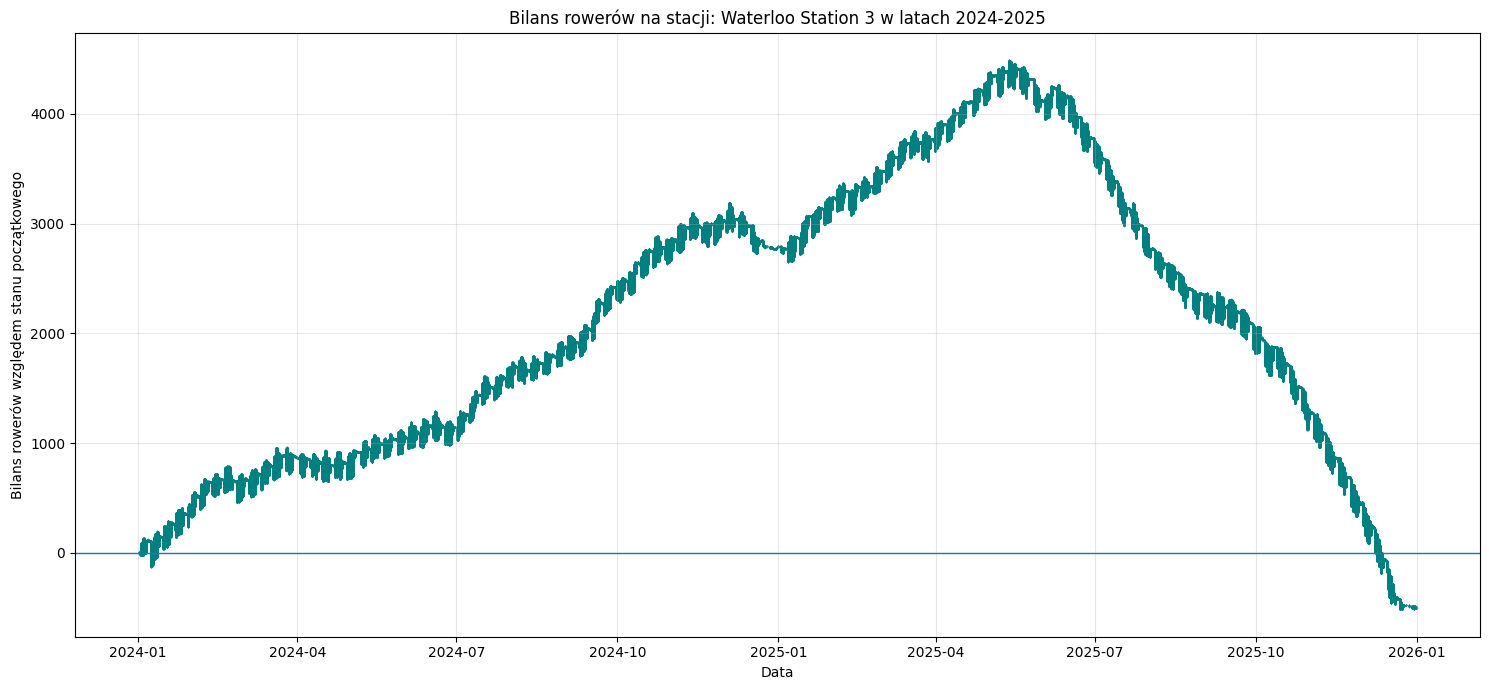

In [114]:
plt.figure(figsize=(15, 7))

plt.scatter(
    station_events["date"],
    station_events["balance"],
    s=0.05,
    color="teal"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Data")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(f"Bilans rowerów na stacji: {station_name_clean} w latach 2024-2025")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [126]:
selected_weekdays = ["2025-08-18", "2025-08-19"]
selected_weekend = ["2025-08-23", "2025-08-24"]

start_weekday = pd.to_datetime(selected_weekdays[0])
end_weekday = pd.to_datetime(selected_weekdays[-1])

date_label = f"{start_weekday.day}-{end_weekday.day} sierpnia 2025"

selected_dates = [pd.to_datetime(day).date() for day in selected_weekdays]

few_day_events = station_events[
    station_events["date"].dt.date.isin(selected_dates)
].copy()

few_day_events = few_day_events.sort_values("date")

few_day_events["balance"] = few_day_events["change"].cumsum()
print(few_day_events["date"].min())
print(few_day_events["date"].max())

2025-08-18 05:17:00
2025-08-19 23:59:00


In [127]:
few_day_events.groupby(few_day_events["date"].dt.date).agg(
    liczba_zdarzen=("date", "count"),
    pierwsze_zdarzenie=("date", "min"),
    ostatnie_zdarzenie=("date", "max")
)

,liczba_zdarzen,pierwsze_zdarzenie,ostatnie_zdarzenie
date,,,
2025-08-18,375,2025-08-18 05:17:00,2025-08-18 22:31:00
2025-08-19,410,2025-08-19 05:38:00,2025-08-19 23:59:00


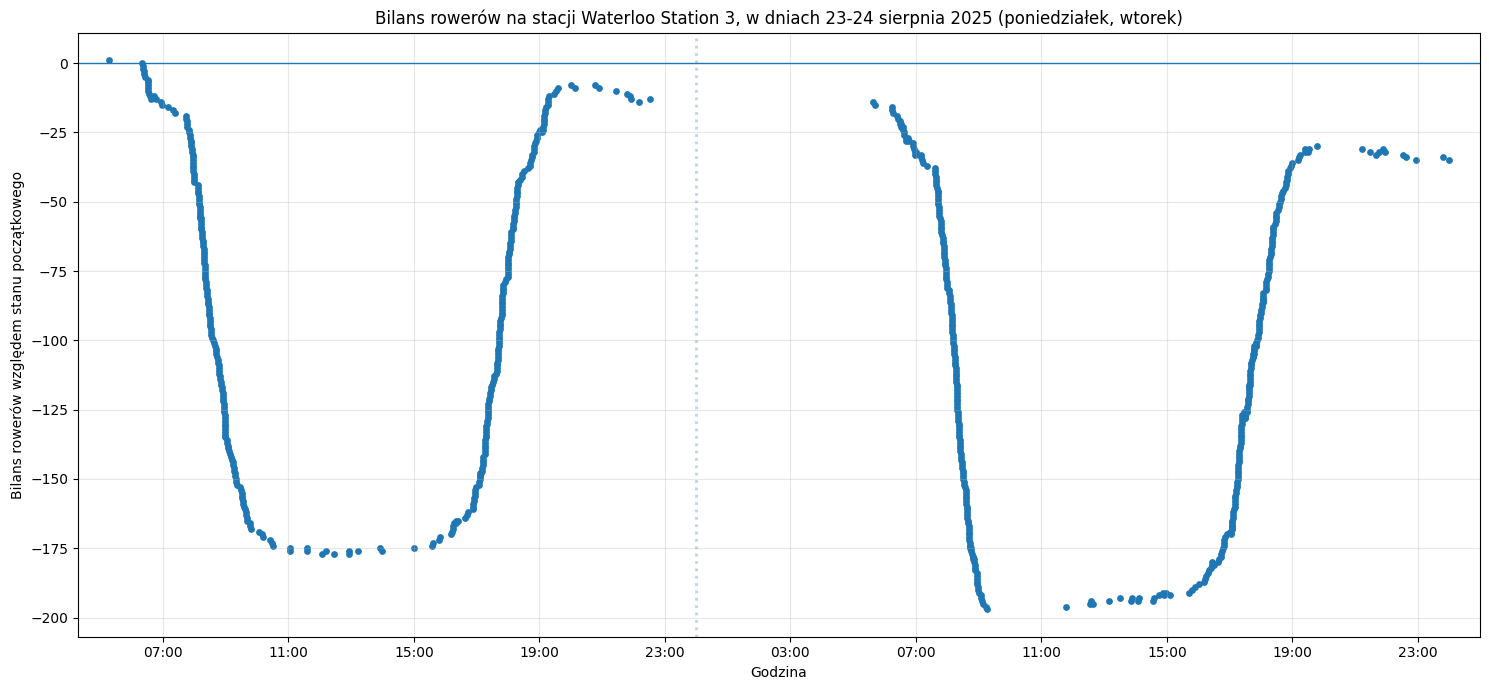

In [136]:
days_pl = {
    "Monday": "poniedziałek",
    "Tuesday": "wtorek",
    "Wednesday": "środa",
    "Thursday": "czwartek",
    "Friday": "piątek",
    "Saturday": "sobota",
    "Sunday": "niedziela"
}

weekdays_label = ", ".join(
    days_pl[pd.to_datetime(day).day_name()] for day in selected_weekdays
)


x_start = few_day_events["date"].min()
x_end = few_day_events["date"].max()

# północe dla wybranych dni
midnights = pd.to_datetime(selected_weekdays)

plt.figure(figsize=(15, 7))

# wykres punktowy zamiast liniowego
plt.scatter(
    few_day_events["date"],
    few_day_events["balance"],
    s=15
)

plt.axhline(0, linewidth=1)
plt.xlim(x_start - pd.Timedelta(hours=1), x_end + pd.Timedelta(hours=1))

# pionowe linie oznaczające północ
for midnight in midnights:
    plt.axvline(
        midnight,
        linestyle=":",
        linewidth=2,
        alpha=0.35,
        color = "steelblue"
    )

plt.xlabel("Godzina")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(
    f"Bilans rowerów na stacji {station_name_clean}, "
    f"w dniach {date_label} ({weekdays_label})"
)

# godziny na osi X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
selected_weekend = ["2025-08-23", "2025-08-24"]

start_weekend = pd.to_datetime(selected_weekend[0])
end_weekend = pd.to_datetime(selected_weekend[-1])

date_label = f"{start_weekend.day}-{end_weekend.day} sierpnia 2025"

selected_dates = [pd.to_datetime(day).date() for day in selected_weekend]

weekend_events = station_events[
    station_events["date"].dt.date.isin(selected_dates)
].copy()

weekend_events = weekend_events.sort_values("date")

weekend_events["balance"] = weekend_events["change"].cumsum()

print(weekend_events["date"].min())
print(weekend_events["date"].max())

2025-08-23 00:01:00
2025-08-24 23:58:00


In [132]:
weekend_events.groupby(weekend_events["date"].dt.date).agg(
    liczba_zdarzen=("date", "count"),
    pierwsze_zdarzenie=("date", "min"),
    ostatnie_zdarzenie=("date", "max")
)

,liczba_zdarzen,pierwsze_zdarzenie,ostatnie_zdarzenie
date,,,
2025-08-23,41,2025-08-23 00:01:00,2025-08-23 23:24:00
2025-08-24,39,2025-08-24 00:13:00,2025-08-24 23:58:00


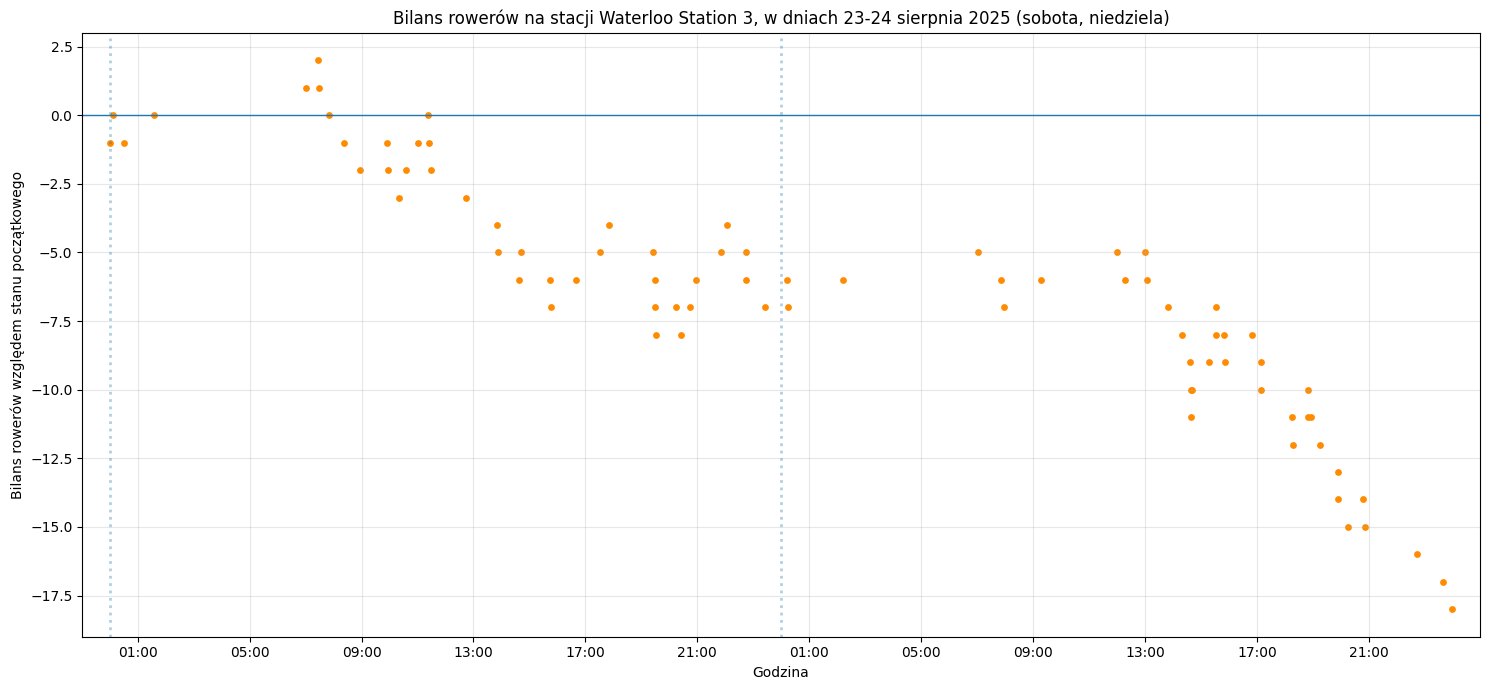

In [135]:
weekend_label = ", ".join(
    days_pl[pd.to_datetime(day).day_name()] for day in selected_weekend
)

x_start = weekend_events["date"].min()
x_end = weekend_events["date"].max()

midnights = pd.to_datetime(selected_weekend)

plt.figure(figsize=(15, 7))

plt.scatter(
    weekend_events["date"],
    weekend_events["balance"],
    s=15,
    color="darkorange"
)

plt.axhline(0, linewidth=1)

plt.xlim(
    x_start - pd.Timedelta(hours=1),
    x_end + pd.Timedelta(hours=1)
)

for midnight in midnights:
    plt.axvline(
        midnight,
        linestyle=":",
        linewidth=2,
        alpha=0.35
    )

plt.xlabel("Godzina")
plt.ylabel("Bilans rowerów względem stanu początkowego")
plt.title(
    f"Bilans rowerów na stacji {station_name_clean}, "
    f"w dniach {date_label} ({weekend_label})"
)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=4))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()